In [102]:
import os
os.environ["QT_API"] = "pyqt5"
os.environ["MNE_3D_OPTION_ANTIALIAS"] = "1"

In [103]:
import numpy as np
import mne
from mne.simulation import simulate_raw, simulate_sparse_stc, add_noise, add_eog
from mne import make_ad_hoc_cov

In [104]:

SFREQ        = 256        # Hz
DURATION_MIN = 5          # minutes
EPOCH_DUR    = 10.0       # seconds per tiled source epoch
N_DIPOLES    = 6          # sparse cortical sources
ALPHA_HZ     = 10.0       # dominant resting frequency
SEED         = 42
OUTPUT       = "resting_eeg_sphere_raw.fif"

rng = np.random.RandomState(SEED)

In [105]:
print("Building channel info …")

montage = mne.channels.make_standard_montage("standard_1020")
ch_names = ['Fp1','Fp2','F7','F3','Fz','F4','F8',
            'T7','C3','Cz','C4','T8',
            'P7','P3','Pz','P4','P8',
            'O1','O2']

info = mne.create_info(ch_names=ch_names, sfreq=SFREQ, ch_types="eeg")
raw = mne.io.RawArray(np.zeros((len(ch_names), 1)), info, verbose=False)
raw.set_montage(montage)
raw = raw.set_eeg_reference("average", projection=False, verbose=False)

Building channel info …


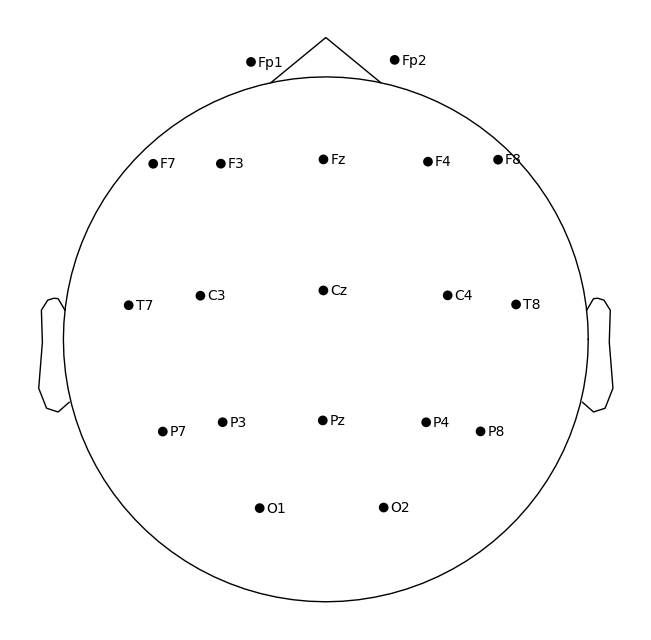

In [9]:
electrode_fig = raw.plot_sensors(show_names = True)

In [106]:
print("Building spherical conductor model …")
sphere = mne.make_sphere_model("auto","auto", raw.info        # outer skull radius
)


Building spherical conductor model …
Fitted sphere radius:         95.6 mm
Origin head coordinates:      -0.9 15.8 45.4 mm
Origin device coordinates:    -0.9 15.8 45.4 mm

Equiv. model fitting -> RV = 0.00347455 %%
mu1 = 0.944856    lambda1 = 0.136823
mu2 = 0.667779    lambda2 = 0.683693
mu3 = -0.294888    lambda3 = -0.0101468
Set up EEG sphere model with scalp radius    95.6 mm



In [7]:
print("Creating volume source space …")
src = mne.setup_volume_source_space(
    pos=15.0,                  # grid spacing in mm
    sphere=sphere,
    sphere_units="m",          # sphere object already in metres
    verbose=False,
)
print(f"  Source space: {src[0]['nuse']} active voxels")

Creating volume source space …
  Source space: 666 active voxels


C:\Users\ingrambz\AppData\Local\Temp\ipykernel_13964\2294434764.py:2: RuntimeWarning: SUBJECTS_DIR in your MNE-Python configuration or environment does not exist, consider using mne.set_config to fix it: C:\Users\ingrambz\mne_data\MNE-fsaverage-data
  src = mne.setup_volume_source_space(


In [8]:
print("Computing EEG forward solution (sphere) …")
fwd = mne.make_forward_solution(
    raw.info,
    trans=None,                # no head↔MRI transform needed for sphere
    src=src,
    bem=sphere,
    eeg=True,
    meg=False,
    verbose=False,
)
print(f"  Forward: {fwd['sol']['data'].shape} (channels × sources)")

Computing EEG forward solution (sphere) …
  Forward: (19, 1998) (channels × sources)


In [9]:
trans = mne.transforms.Transform("head", "mri", np.eye(4))
mne.viz.plot_alignment(
    info=raw.info,
    bem=sphere,
    trans=trans,
    eeg=[ 'projected'],  # <-- was: eeg=True
    dig=True,
    surfaces='head',
)

Using pyvistaqt 3d backend.
Channel types::	eeg: 19
Projecting sensors to the head surface


In [23]:

src = mne.setup_volume_source_space(sphere=sphere, pos=10.0)
mne.viz.plot_alignment(
    raw.info,
    trans=trans,
    eeg="projected",
    bem=sphere,
    src=src,
    dig=True,
    surfaces='head',
    show_axes=True,
)

Sphere                : origin at (0.0 0.0 0.0) mm
              radius  : 81.0 mm
grid                  : 10.0 mm
mindist               : 5.0 mm

Setting up the sphere...
Surface CM = (   0.0    0.0    0.0) mm
Surface fits inside a sphere with radius   81.0 mm
Surface extent:
    x =  -81.0 ...   81.0 mm
    y =  -81.0 ...   81.0 mm
    z =  -81.0 ...   81.0 mm
Grid extent:
    x =  -90.0 ...   90.0 mm
    y =  -90.0 ...   90.0 mm
    z =  -90.0 ...   90.0 mm
6859 sources before omitting any.
2205 sources after omitting infeasible sources not within 0.0 - 81.0 mm.
Source spaces are in MRI coordinates.
Checking that the sources are inside the surface and at least    5.0 mm away (will take a few...)
    366 source space point omitted because of the    5.0-mm distance limit.
1839 sources remaining after excluding the sources outside the surface and less than    5.0 mm inside.
Adjusting the neighborhood info.
Source space : MRI voxel -> MRI (surface RAS)
    0.010000 0.000000 0.000000    

C:\Users\ingrambz\AppData\Local\Temp\ipykernel_30320\781427587.py:1: RuntimeWarning: SUBJECTS_DIR in your MNE-Python configuration or environment does not exist, consider using mne.set_config to fix it: C:\Users\ingrambz\mne_data\MNE-fsaverage-data
  src = mne.setup_volume_source_space(sphere=sphere, pos=10.0)


Channel types::	eeg: 19
Projecting sensors to the head surface


### Simulate Data

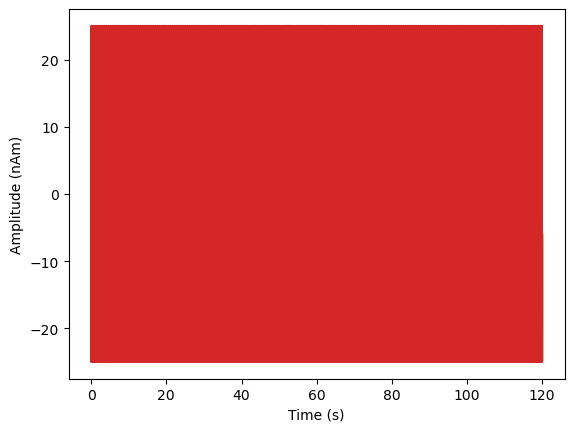

In [28]:
import matplotlib.pyplot as plt 
n_dipoles = 4  # number of dipoles to create
epoch_duration = 2.0  # duration of each epoch/event
n = 0  # harmonic number
rng = np.random.RandomState(0)  # random state (make reproducible)


def data_fun(times):
    return 25e-9 * np.sin(2 * np.pi * 10 * times)


sfreq = raw.info["sfreq"]  # sampling frequency (Hz)
duration = 120.0  # 2 minutes in seconds

n_samp = int(sfreq * duration)
times = np.arange(n_samp) / sfreq

src = fwd["src"]
stc = simulate_sparse_stc(
    src, n_dipoles=n_dipoles, times=times, data_fun=data_fun, random_state=rng
)

# look at our source data
fig, ax = plt.subplots(1)
ax.plot(times, 1e9 * stc.data.T)
ax.set(ylabel="Amplitude (nAm)", xlabel="Time (s)")
mne.viz.utils.plt_show()

In [62]:
stc = simulate_sparse_stc(
    fwd["src"],
    n_dipoles=1,
    times=times,
    data_fun=data_fun,
    random_state=0
)

In [63]:
raw.info

<Info | 9 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F7, F3, Fz, F4, F8, T7, C3, Cz, C4, T8, P7, P3, Pz, ...
 chs: 19 EEG
 custom_ref_applied: True
 dig: 22 items (3 Cardinal, 19 EEG)
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: unspecified
 nchan: 19
 projs: []
 sfreq: 256.0 Hz
>

In [59]:
info = raw.info.copy()
info["dev_head_t"] = fwd["info"]["dev_head_t"]
raw_sim = simulate_raw(info, [stc] * 10, forward=fwd, verbose=True)
cov = make_ad_hoc_cov(raw_sim.info)
add_noise(raw_sim, cov, iir_filter=[0.2, -0.2, 0.04], random_state=rng)
#add_ecg(raw_sim, random_state=rng)
add_eog(raw_sim, random_state=rng)

Setting up raw simulation: 1 position, "cos2" interpolation
Event information not stored
    Interval 0.000–120.000 s
Setting up forward solutions
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    10 STC iterations provided
[done]
Adding noise to 19/19 channels (19 channels in cov)
Sphere                : origin at (0.0 0.0 0.0) mm
              radius  : 0.1 mm
Source location file  : dict()
Assuming input in millimeters
Assuming input in MRI coordinates

Positions (in meters) and orientations
2 sources
blink simulated and trace not stored
Setting up forward solutions


C:\Users\ingrambz\AppData\Local\Temp\ipykernel_30320\2403221597.py:7: RuntimeWarning: SUBJECTS_DIR in your MNE-Python configuration or environment does not exist, consider using mne.set_config to fix it: C:\Users\ingrambz\mne_data\MNE-fsaverage-data
  add_eog(raw_sim, random_state=rng)


In [60]:
raw_sim.plot()

<mne_qt_browser._pg_figure.MNEQtBrowser(0x263c4801c10) at 0x0000026409E51EC0>

Channels marked as bad:
none


Effective window size : 8.000 (s)


Plotting power spectral density (dB=True).


c:\Users\ingrambz\AppData\Local\mne-python\1.11.0_0\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


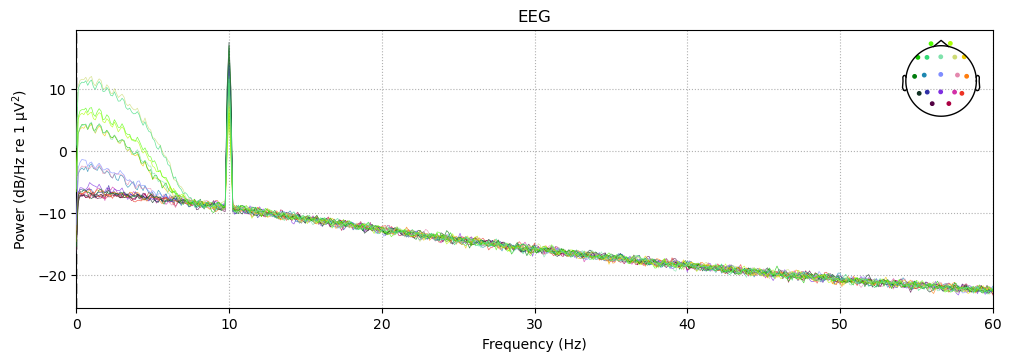

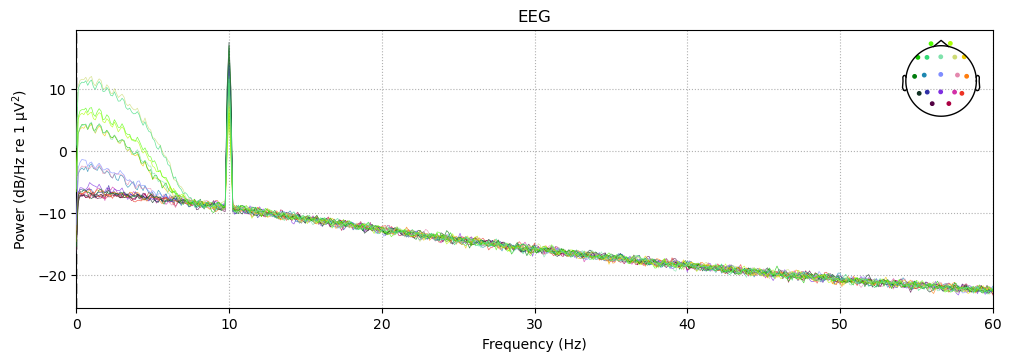

In [61]:
raw_sim.compute_psd(fmax = 60).plot(dB=True)

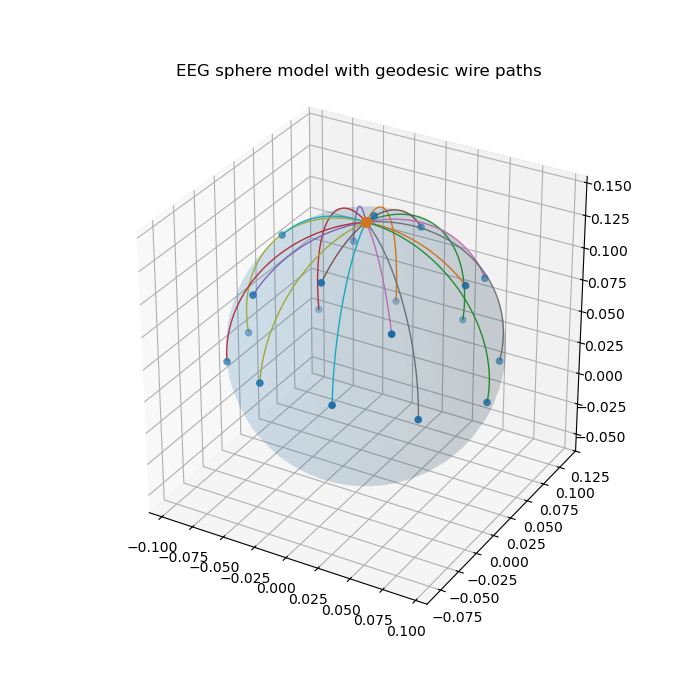

In [107]:
import numpy as np
import matplotlib.pyplot as plt
import mne

%matplotlib widget

# =========================================================
# 1. SPHERE GEOMETRY (from your MNE model)
# =========================================================
center = np.array(sphere['r0'])
radius = max(layer['rad'] for layer in sphere['layers'])

# =========================================================
# 2. ELECTRODE POSITIONS (correct MNE-aligned version)
# =========================================================
coords = []
ch_names = []

for ch in raw.info['chs']:
    if ch['kind'] == mne.io.constants.FIFF.FIFFV_EEG_CH:
        loc = ch['loc'][:3]
        if not np.allclose(loc, 0):
            coords.append(loc)
            ch_names.append(ch['ch_name'])

coords = np.array(coords)

# =========================================================
# 3. PROJECT ELECTRODES TO SPHERE
# =========================================================
def project_to_sphere(points, center, radius):
    vecs = points - center
    vecs /= np.linalg.norm(vecs, axis=1, keepdims=True)
    return center + vecs * radius

coords_proj = project_to_sphere(coords, center, radius)

# =========================================================
# 4. GREAT CIRCLE ARC FUNCTION
# =========================================================
def great_circle_arc(p1, p2, center, radius, n=50):
    # shift to origin
    p1 = p1 - center
    p2 = p2 - center

    # normalize to unit sphere
    p1 = p1 / np.linalg.norm(p1)
    p2 = p2 / np.linalg.norm(p2)

    # angle between vectors
    omega = np.arccos(np.clip(np.dot(p1, p2), -1, 1))

    if omega < 1e-6:
        return np.tile(center + p1 * radius, (n, 1))

    t = np.linspace(0, 1, n)
    sin_omega = np.sin(omega)

    arc = (
        np.sin((1 - t) * omega)[:, None] * p1 +
        np.sin(t * omega)[:, None] * p2
    ) / sin_omega

    return center + arc * radius

# =========================================================
# 5. SPHERE SURFACE (for plotting)
# =========================================================
u = np.linspace(0, 2*np.pi, 60)
v = np.linspace(0, np.pi, 60)

x = center[0] + radius * np.outer(np.cos(u), np.sin(v))
y = center[1] + radius * np.outer(np.sin(u), np.sin(v))
z = center[2] + radius * np.outer(np.ones_like(u), np.cos(v))

# =========================================================
# 6. PLOT
# =========================================================
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# sphere
ax.plot_surface(x, y, z, alpha=0.1)

# electrodes
ax.scatter(coords_proj[:, 0],
           coords_proj[:, 1],
           coords_proj[:, 2],
           s=20)

# top of head (wire origin)
top = center + np.array([0, 0, radius])
ax.scatter(*top, s=50)

# =========================================================
# 7. WIRES (top → each electrode)
# =========================================================
for ep in coords_proj:
    arc = great_circle_arc(top, ep, center, radius)
    ax.plot(arc[:, 0], arc[:, 1], arc[:, 2], linewidth=1)

# aesthetics
ax.set_box_aspect([1, 1, 1])
ax.set_title("EEG sphere model with geodesic wire paths")

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import mne

class SphereModel:
    def great_circle_arc(p1, p2, center, radius, n=50):
        # shift to origin
        p1 = p1 - center
        p2 = p2 - center

        # normalize to unit sphere
        p1 = p1 / np.linalg.norm(p1)
        p2 = p2 / np.linalg.norm(p2)

        # angle between vectors
        omega = np.arccos(np.clip(np.dot(p1, p2), -1, 1))

        if omega < 1e-6:
            return np.tile(center + p1 * radius, (n, 1))

        t = np.linspace(0, 1, n)
        sin_omega = np.sin(omega)

        arc = (
            np.sin((1 - t) * omega)[:, None] * p1 +
            np.sin(t * omega)[:, None] * p2
        ) / sin_omega

        return center + arc * radius

    def __init__(self, info=None):
        # Create initial sphere
        print("Creating sphere model...")
        self.info = info
        mne_sphere = mne.make_sphere_model("auto","auto", info)
        self.center = np.array(mne_sphere['r0'])
        self.radius = max(layer['rad'] for layer in mne_sphere['layers'])
        self.top = self.center + np.array([0, 0, self.radius])

        # Extract electrode positions and store
        print("Storing electrode positions...")
        eeg_coords_orig = []
        ch_names = []
        for ch in info['chs']:
            if ch['kind'] == mne.io.constants.FIFF.FIFFV_EEG_CH:
                loc = ch['loc'][:3]
            if not np.allclose(loc, 0):
                eeg_coords_orig.append(loc)
                ch_names.append(ch['ch_name'])
        
        self.eeg_coords_orig = np.array(eeg_coords_orig)

        # Project Electrode Positions to sphere
        self.vecs = eeg_coords_orig - self.center
        self.vecs /= np.linalg.norm(self.vecs, axis=1, keepdims=True)
        self.eeg_coords_proj = self.center + self.vecs * self.radius

        # Calculate wire trajetories
        self.wires = []
        for ep in self.eeg_coords_proj:
            arc = great_circle_arc(self.top, ep, self.center, self.radius)
            self.wires.append(arc)

    def plot_sphere(self):
        u = np.linspace(0, 2*np.pi, 60)
        v = np.linspace(0, np.pi, 60)

        x = self.center[0] + self.radius * np.outer(np.cos(u), np.sin(v))
        y = self.center[1] + self.radius * np.outer(np.sin(u), np.sin(v))
        z = self.center[2] + self.radius * np.outer(np.ones_like(u), np.cos(v))

        fig = plt.figure(figsize=(7, 7))
        ax = fig.add_subplot(111, projection='3d')
        # plot electrodes
        ax.scatter(self.eeg_coords_proj[:, 0],
           self.eeg_coords_proj[:, 1],
           self.eeg_coords_proj[:, 2],
           s=20)

        ax.plot_surface(x, y, z, alpha=0.1)
        ax.set_box_aspect([1, 1, 1])
        # top of head (wire origin)
        ax.scatter(*self.top, s=50)

        # plot cables
        for wire in self.wires:
            ax.plot(wire[:, 0], wire[:, 1], wire[:, 2], linewidth=1)

        ax.set_title("EEG sphere model with geodesic wire paths")
        plt.show()
        
    def simulate_eeg(self, alpha = True, blinks = True):
        # Source space
        self.src = mne.setup_volume_source_space(
            pos=15.0,                  # grid spacing in mm
            sphere=sphere,
            sphere_units="m",          # sphere object already in metres
            verbose=False,
        )

        # Forward Model
        self.fwd = mne.make_forward_solution(
            self.info,
            trans=None,       
            src=self.src,
            bem=sphere,
            eeg=True,
            meg=False,
            verbose=False,
        )
        
        import matplotlib.pyplot as plt 
        n_dipoles = 1  # number of dipoles to create
        n = 1  # harmonic number
        rng = np.random.RandomState(0)  # random state (make reproducible)


        def data_fun(times):
            return 25e-9 * np.sin(2 * np.pi * 10 * times)


        sfreq = self.info["sfreq"]  # sampling frequency (Hz)
        duration = 120.0  # 2 minutes in seconds

        n_samp = int(sfreq * duration)
        times = np.arange(n_samp) / sfreq

        stc = simulate_sparse_stc(
            self.src, n_dipoles=n_dipoles, times=times, data_fun=data_fun, random_state=rng
        )

        self.info["dev_head_t"] = self.fwd["info"]["dev_head_t"]
        raw_sim = simulate_raw(info, [stc] * 10, forward=self.fwd, verbose=True)
        cov = make_ad_hoc_cov(raw_sim.info)
        add_noise(raw_sim, cov, iir_filter=[0.2, -0.2, 0.04], random_state=rng)
        #add_ecg(raw_sim, random_state=rng)
        add_eog(raw_sim, random_state=rng)
        raw_sim.plot()
    
    def simulate_gradients(self, TR, echo_time, slices=32, multiband=2):
        print()

    def simulate_bcg(self, TR, echo_time, slices=32, multiband=2):
        print()
    

In [214]:
montage = mne.channels.make_standard_montage("standard_1020")
#montage = mne.channels.make_standard_montage("biosemi32")

info = mne.create_info(ch_names=montage.ch_names, sfreq=5000.0, ch_types="eeg")
info.set_montage(montage)

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fpz, Fp2, AF9, AF7, AF5, AF3, AF1, AFz, AF2, AF4, AF6, AF8, ...
 chs: 94 EEG
 custom_ref_applied: False
 dig: 97 items (3 Cardinal, 94 EEG)
 highpass: 0.0 Hz
 lowpass: 2500.0 Hz
 meas_date: unspecified
 nchan: 94
 projs: []
 sfreq: 5000.0 Hz
>

In [215]:
test = SphereModel(info)

Creating sphere model...
Fitted sphere radius:         98.4 mm
Origin head coordinates:      -1.0 13.9 39.1 mm
Origin device coordinates:    -1.0 13.9 39.1 mm

Equiv. model fitting -> RV = 0.00481265 %%
mu1 = 0.943693    lambda1 = 0.139996
mu2 = 0.662653    lambda2 = 0.69485
mu3 = 0.260763    lambda3 = -0.0244758
Set up EEG sphere model with scalp radius    98.4 mm

Storing electrode positions...


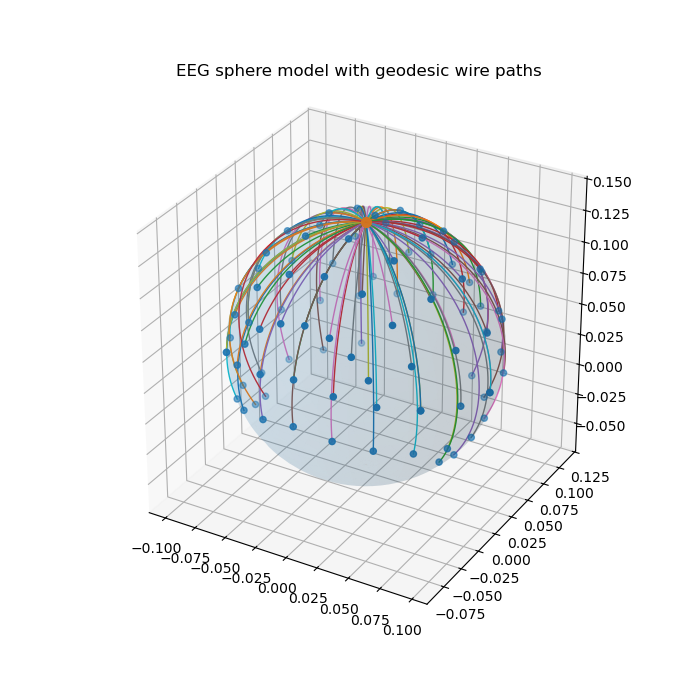

In [216]:
%matplotlib widget
test.plot_sphere()

In [217]:
test.simulate_eeg()

Setting up raw simulation: 1 position, "cos2" interpolation
Event information not stored
    Interval 0.000–120.000 s
Setting up forward solutions


C:\Users\ingrambz\AppData\Local\Temp\ipykernel_24912\45206209.py:94: RuntimeWarning: SUBJECTS_DIR in your MNE-Python configuration or environment does not exist, consider using mne.set_config to fix it: C:\Users\ingrambz\mne_data\MNE-fsaverage-data
  self.src = mne.setup_volume_source_space(


    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    10 STC iterations provided
[done]
Adding noise to 94/94 channels (94 channels in cov)


C:\Users\ingrambz\AppData\Local\Temp\ipykernel_24912\45206209.py:135: RuntimeWarning: No average EEG reference present in info["projs"], covariance may be adversely affected. Consider recomputing covariance using with an average eeg reference projector added.
  add_noise(raw_sim, cov, iir_filter=[0.2, -0.2, 0.04], random_state=rng)


Sphere                : origin at (0.0 0.0 0.0) mm
              radius  : 0.1 mm
Source location file  : dict()
Assuming input in millimeters
Assuming input in MRI coordinates

Positions (in meters) and orientations
2 sources
blink simulated and trace not stored
Setting up forward solutions


C:\Users\ingrambz\AppData\Local\Temp\ipykernel_24912\45206209.py:137: RuntimeWarning: SUBJECTS_DIR in your MNE-Python configuration or environment does not exist, consider using mne.set_config to fix it: C:\Users\ingrambz\mne_data\MNE-fsaverage-data
  add_eog(raw_sim, random_state=rng)


Using qt as 2D backend.


### Test Gradient Simulation

In [3]:
"""
EPI (Echo Planar Imaging) — PyPulseq
pip install pypulseq matplotlib numpy
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pypulseq as pp

# ══════════════════════════════════════════════
# SEQUENCE PARAMETERS
# ══════════════════════════════════════════════
FOV        = 220e-3    # m
N_RO       = 64
N_PE       = 64
SLICE_THK  = 3e-3      # m
N_SLICES   = 20
TR         = 1.5       # s
TE         = 35e-3     # s
FLIP_DEG   = 77

# Dwell must satisfy: N_RO * dwell = integer * grad_raster (10 us)
# Use 10 us -> BW = 1/(10e-6 * 64) = 1562.5 Hz/px (realistic for fMRI)
DWELL = 10e-6          # s per sample

SYSTEM = pp.Opts(
    max_grad=40, grad_unit="mT/m",
    max_slew=150, slew_unit="T/m/s",
    rf_ringdown_time=20e-6, rf_dead_time=100e-6,
    adc_dead_time=10e-6,
    grad_raster_time=10e-6,
    rf_raster_time=1e-6,
    adc_raster_time=100e-9,
    block_duration_raster=10e-6,
)

# ══════════════════════════════════════════════
# DERIVED
# ══════════════════════════════════════════════
GAMMA       = 42.577e6               # Hz/T
delta_k     = 1.0 / FOV
k_width     = N_RO * delta_k
readout_time = DWELL * N_RO          # flat-top of Gx = 640 us

# ══════════════════════════════════════════════
# EVENTS
# ══════════════════════════════════════════════
rf, gz_ss, gz_reph = pp.make_sinc_pulse(
    flip_angle=FLIP_DEG * np.pi / 180,
    duration=3e-3, slice_thickness=SLICE_THK,
    apodization=0.5, time_bw_product=4,
    system=SYSTEM, return_gz=True,
)

gx_ro = pp.make_trapezoid(
    channel="x", flat_area=k_width, flat_time=readout_time, system=SYSTEM
)
gx_ro_neg = pp.scale_grad(gx_ro, -1)

adc = pp.make_adc(
    num_samples=N_RO, duration=readout_time,
    delay=gx_ro.rise_time, system=SYSTEM
)

gx_pre = pp.make_trapezoid(channel="x", area=-gx_ro.area / 2, system=SYSTEM)

blip_dur = gx_ro.rise_time + gx_ro.fall_time
gy_blip  = pp.make_trapezoid(channel="y", area=delta_k, duration=blip_dur, system=SYSTEM)
gy_pre   = pp.make_trapezoid(channel="y", area=-N_PE / 2 * delta_k, system=SYSTEM)

# ══════════════════════════════════════════════
# TE TIMING
# ══════════════════════════════════════════════
echo_spacing = pp.calc_duration(gx_ro)

t_to_kc = (pp.calc_duration(gz_reph)
           + pp.calc_duration(gx_pre)
           + (N_PE // 2) * echo_spacing)

delay_te = TE - t_to_kc - pp.calc_duration(gz_ss) / 2
delay_te = round(delay_te / SYSTEM.block_duration_raster) * SYSTEM.block_duration_raster
assert delay_te >= 0, "TE too short"

# ══════════════════════════════════════════════
# ASSEMBLE
# ══════════════════════════════════════════════
seq = pp.Sequence(system=SYSTEM)
seq.add_block(rf, gz_ss)
seq.add_block(gz_reph, gx_pre, gy_pre, pp.make_delay(delay_te))

for line in range(N_PE):
    gx = gx_ro if line % 2 == 0 else gx_ro_neg
    if line < N_PE - 1:
        seq.add_block(gx, adc, gy_blip)
    else:
        seq.add_block(gx, adc)

t_used = (pp.calc_duration(gz_ss) + delay_te
          + pp.calc_duration(gz_reph) + N_PE * echo_spacing)
tr_delay = TR / N_SLICES - t_used
tr_delay = round(tr_delay / SYSTEM.block_duration_raster) * SYSTEM.block_duration_raster
assert tr_delay >= 0, "TR too short"
seq.add_block(pp.make_delay(tr_delay))

ok, errs = seq.check_timing()
print("Timing OK:", ok)
seq.write("epi_sequence.seq")

# ══════════════════════════════════════════════
# PRINT SUMMARY
# ══════════════════════════════════════════════
print(f"\n  Matrix       : {N_RO} x {N_PE}")
print(f"  FOV          : {FOV*1e3:.0f} mm")
print(f"  Slice thk    : {SLICE_THK*1e3:.1f} mm  x{N_SLICES}")
print(f"  TE / TR      : {TE*1e3:.0f} / {TR*1e3:.0f} ms")
print(f"  Echo spacing : {echo_spacing*1e3:.2f} ms")
print(f"  EPI train    : {N_PE * echo_spacing * 1e3:.1f} ms")
print(f"  BW per pixel : {1/DWELL/N_RO:.1f} Hz")
print(f"  Gx readout   : {gx_ro.amplitude/GAMMA*1e3:.2f} mT/m")
print(f"  Gz slice-sel : {gz_ss.amplitude/GAMMA*1e3:.2f} mT/m")

# ══════════════════════════════════════════════
# PLOT WAVEFORMS
# ══════════════════════════════════════════════
def extract_waveforms(seq):
    t_gx, gx = [0.], [0.]
    t_gy, gy = [0.], [0.]
    t_gz, gz = [0.], [0.]
    t_rf, rf_env = [], []
    adc_wins = []
    t0 = 0.0

    for blk_idx in seq.block_events:
        blk = seq.get_block(blk_idx)
        dur = pp.calc_duration(blk)

        def add_trap(ta, va, trap):
            if trap is None:
                ta += [t0, t0+dur]; va += [0., 0.]; return
            d = trap.delay if hasattr(trap, "delay") else 0.
            amp = trap.amplitude
            for tt, vv in [
                (t0, 0.), (t0+d, 0.),
                (t0+d+trap.rise_time, amp),
                (t0+d+trap.rise_time+trap.flat_time, amp),
                (t0+d+trap.rise_time+trap.flat_time+trap.fall_time, 0.),
                (t0+dur, 0.)
            ]:
                ta.append(tt); va.append(vv)

        add_trap(t_gx, gx, getattr(blk, "gx", None))
        add_trap(t_gy, gy, getattr(blk, "gy", None))
        add_trap(t_gz, gz, getattr(blk, "gz", None))

        rf_blk = getattr(blk, "rf", None)
        if rf_blk is not None:
            tpts = t0 + rf_blk.delay + rf_blk.t
            env = np.abs(rf_blk.signal)
            t_rf.extend(tpts); rf_env.extend(env / (env.max() + 1e-12))

        adc_blk = getattr(blk, "adc", None)
        if adc_blk is not None:
            ta = t0 + adc_blk.delay
            adc_wins.append((ta, ta + adc_blk.num_samples * adc_blk.dwell))

        t0 += dur

    ms = 1e3
    return (np.array(t_gx)*ms, np.array(gx)/GAMMA*1e3,
            np.array(t_gy)*ms, np.array(gy)/GAMMA*1e3,
            np.array(t_gz)*ms, np.array(gz)/GAMMA*1e3,
            np.array(t_rf)*ms, np.array(rf_env),
            [(a*ms, b*ms) for a,b in adc_wins])

t_gx,gx,t_gy,gy,t_gz,gz,t_rf,rf_env,adc_wins = extract_waveforms(seq)

fig, axes = plt.subplots(4, 1, figsize=(15, 9), sharex=True)
labels = ["RF (norm.)", "Gx (mT/m)", "Gy (mT/m)", "Gz (mT/m)"]
colors = ["#c084fc", "#60a5fa", "#34d399", "#fb923c"]
data   = [(t_rf, rf_env), (t_gx, gx), (t_gy, gy), (t_gz, gz)]

for ax, (tx, vals), col, lbl in zip(axes, data, colors, labels):
    ax.plot(tx, vals, color=col, linewidth=1.0)
    ax.fill_between(tx, vals, alpha=0.15, color=col)
    ax.axhline(0, color="#555", linewidth=0.6)
    ax.set_ylabel(lbl, fontsize=9)
    ax.grid(True, alpha=0.3, linewidth=0.4)

# shade ADC windows on Gx panel
for ta, tb in adc_wins:
    axes[1].axvspan(ta, tb, alpha=0.15, color="#34d399")

axes[3].set_xlabel("Time (ms)", fontsize=9)
fig.suptitle(f"GRE-EPI  {N_RO}x{N_PE}  FOV {FOV*1e3:.0f}mm  "
             f"TE/TR {TE*1e3:.0f}/{TR*1e3:.0f}ms  ES {echo_spacing*1e3:.2f}ms", fontsize=10)
fig.tight_layout()
plt.savefig("epi_waveforms.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved epi_waveforms.png")

C:\Users\ingrambz\AppData\Local\Temp\ipykernel_27860\3192093615.py:49: UserWarning: Specified RF delay 0.00 us is less than the dead time 100 us. Delay was increased to the dead time.
  rf, gz_ss, gz_reph = pp.make_sinc_pulse(


Timing OK: True

  Matrix       : 64 x 64
  FOV          : 220 mm
  Slice thk    : 3.0 mm  x20
  TE / TR      : 35 / 1500 ms
  Echo spacing : 0.80 ms
  EPI train    : 51.2 ms
  BW per pixel : 1562.5 Hz
  Gx readout   : 10.68 mT/m
  Gz slice-sel : 10.44 mT/m
Saved epi_waveforms.png


### test lead induction

In [ ]:
"""
V_lead Forward Model — Wire Contribution to Gradient Artefact
=============================================================

This script computes ONLY the V_lead term of the gradient artefact:

    V_lead = ∫ E_ind · dl

    where:
        E_ind   = −∂A/∂t  = induced electric field (V/m)
        dl      = tiny step along the wire (m)
        ∫       = integrate (sum up) along the entire wire path

This is the simpler of the two contributions (V_lead + V_electrode).
V_electrode (the head tissue / Laplace term) is NOT included here.

Physical setup
--------------
When an MRI gradient G_z switches at rate dG_z/dt (the slew rate),
it creates a time-varying magnetic field across the scanner bore.
By Faraday's law, this induces an electric field E_ind everywhere
in space — including inside the EEG wire leads.

For a Gz gradient, E_ind swirls in the xy plane:

    E_ind(x, y, z) = (dGz/dt)/2 * (−y,  +x,  0)
                                     │     │    │
                                  x-comp  y-comp  z-comp

This field pushes charges along the wire. The total voltage
that builds up from electrode to amplifier is:

    V_lead = ∫ E_ind · dl  (line integral along wire path)

Reference
---------
Yan WX, Mullinger KJ, Brookes MJ, Bowtell R (2009).
Understanding gradient artefacts in simultaneous EEG/fMRI.
NeuroImage 46(2): 459-471.
"""

import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import mne


# =============================================================================
# STEP 1 — The induced electric field E_ind
# =============================================================================
#
# From Faraday's law and the vector potential:
#
#     E_ind = −∂A/∂t
#
# For a LINEAR gradient G_alpha switching at slew rate dG/dt,
# the induced electric field at position (x, y, z) is:
#
#     Gz:  E_ind = (dGz/dt)/2 * (−y,  +x,   0)   swirls in xy plane
#     Gx:  E_ind = (dGx/dt)/2 * ( 0,  −z,  +y)   swirls in yz plane
#     Gy:  E_ind = (dGy/dt)/2 * (+z,   0,  −x)   swirls in xz plane
#
# This comes from solving the Maxwell equation:
#     ∇ × E = −∂B/∂t
# for a linear gradient field.
#
# Note: the /2 factor comes from the geometry of a linear gradient.
# It appears in the full derivation in the Yan 2009 appendix.

def e_ind(position_m, axis, slew_rate):
    """
    Compute the induced electric field vector E_ind at a single point
    in space, for a given gradient axis and slew rate.

    This is E_ind = −∂A/∂t evaluated at one (x, y, z) location.

    Parameters
    ----------
    position_m : array (3,)
        Position (x, y, z) in metres, relative to gradient isocentre.
        x = left(-) to right(+)
        y = posterior(-) to anterior(+)
        z = inferior(-) to superior(+)

    axis : str
        Gradient axis: 'x', 'y', or 'z'
        In EPI: 'z' = slice select, 'x' = frequency encode, 'y' = phase encode

    slew_rate : float
        dG/dt in T/m/s — how fast the gradient is switching.
        Typical scanner values: 50-200 T/m/s

    Returns
    -------
    E : array (3,)
        Induced electric field vector (Ex, Ey, Ez) in V/m
    """
    x, y, z = position_m
    half_slew = slew_rate / 2.0     # the /2 factor from the gradient geometry

    if axis == 'z':
        # Gz: field swirls in xy plane
        # E_ind = (dGz/dt)/2 * (−y, +x, 0)
        # Physical meaning: Gz varies along z, so it drives a rotational
        # E field in the transverse (xy) plane
        Ex = -half_slew * y
        Ey = +half_slew * x
        Ez =  0.0

    elif axis == 'x':
        # Gx: field swirls in yz plane
        # E_ind = (dGx/dt)/2 * (0, −z, +y)
        Ex =  0.0
        Ey = -half_slew * z
        Ez = +half_slew * y

    elif axis == 'y':
        # Gy: field swirls in xz plane
        # E_ind = (dGy/dt)/2 * (+z, 0, −x)
        Ex = +half_slew * z
        Ey =  0.0
        Ez = -half_slew * x

    else:
        raise ValueError(f"axis must be 'x', 'y' or 'z', got '{axis}'")

    return np.array([Ex, Ey, Ez])

# =============================================================================
# STEP 3 — The line integral  ∫ E_ind · dl
# =============================================================================
#
# The line integral sums up contributions along the wire:
#
#     V_lead = ∫ E_ind · dl
#            ≈ Σ  E_ind(r_i) · (r_{i+1} − r_i)
#               i
#
# At each tiny step from point r_i to r_{i+1}:
#   1. dl = r_{i+1} − r_i              (the tiny displacement vector)
#   2. E_ind(r_i)                       (the field at that point)
#   3. E_ind · dl = Ex*dlx + Ey*dly + Ez*dlz  (dot product)
#
# The dot product picks out how much of E_ind points ALONG the wire
# at that step. Sum all these up → total voltage in wire.

def compute_vlead(wire_path, axis, slew_rate):
    """
    Compute V_lead = ∫ E_ind · dl along a wire path.

    This is the discrete (numerical) version of the line integral:

        V_lead ≈ Σ E_ind(r_i) · (r_{i+1} − r_i)

    Parameters
    ----------
    wire_path : array (N, 3)
        3D coordinates of N points along the wire, in metres.
        From electrode end to amplifier end.

    axis : str
        Gradient axis ('x', 'y', or 'z')

    slew_rate : float
        dG/dt in T/m/s

    Returns
    -------
    V_lead : float
        Induced voltage in the wire, in Volts.
        Multiply by 1e6 to get μV.

    contributions : array (N-1,)
        The contribution E·dl at each tiny wire segment.
        Useful for visualising where along the wire the voltage builds up.
    """
    N = len(wire_path)
    contributions = np.zeros(N - 1)

    for i in range(N - 1):

        # ── Current position along the wire ──
        r_i = wire_path[i]           # 3D position at step i   (metres)

        # ── The tiny displacement vector dl ──
        # This is the vector from current point to next point.
        # It points along the wire and has magnitude = step length.
        dl = wire_path[i + 1] - wire_path[i]    # shape (3,), units: metres

        # ── The induced electric field at this position ──
        # E_ind = −∂A/∂t evaluated at r_i
        # Units: V/m
        E = e_ind(r_i, axis, slew_rate)          # shape (3,), units: V/m

        # ── Dot product: E_ind · dl ──
        # This is: Ex*dlx + Ey*dly + Ez*dlz
        # Units: (V/m) * m = V  ← this tiny step contributes this many Volts
        #
        # Physically: how much does E_ind push charges ALONG the wire here?
        # If E points along dl → large contribution
        # If E points perpendicular to dl → zero contribution
        contributions[i] = np.dot(E, dl)

    # Sum all contributions → total V_lead
    V_lead = np.sum(contributions)

    return V_lead, contributions


# =============================================================================
# STEP 4 — Apply to all electrodes in an MNE Raw object
# =============================================================================

def compute_vlead_all_channels(raw, slew_rate=120.0, axis='z',
                               amp_offset_m=0.3):
    """
    Compute V_lead for every EEG channel in an MNE Raw object.

    Uses the electrode positions from raw.info (via the montage),
    approximates each wire path as electrode → crown → amplifier,
    and computes the line integral for each channel.

    Parameters
    ----------
    raw : mne.io.BaseRaw
        MNE Raw object with a montage set (electrode positions available).

    slew_rate : float
        Gradient slew rate in T/m/s. Default 120 T/m/s (typical 3T scanner).

    axis : str
        Gradient axis to simulate: 'x', 'y', or 'z'.
        'z' = slice select (Gz) — usually dominant
        'x' = frequency encode (Gx)
        'y' = phase encode (Gy)

    amp_offset_m : float
        How far above the head the amplifier sits, in metres.
        The amplifier is placed at (0, 0, head_radius + amp_offset_m).
        Default 0.3 m (30 cm above head centre — just outside bore).

    Returns
    -------
    results : dict with keys:
        'ch_names'      : list of channel names
        'vlead_v'       : array (n_ch,) V_lead in Volts
        'vlead_uv'      : array (n_ch,) V_lead in microvolts
        'positions'     : array (n_ch, 3) electrode positions in metres
        'wire_paths'    : list of (N, 3) arrays — one per channel
        'contributions' : list of (N-1,) arrays — E·dl at each step
        'head_radius_m' : float, head radius in metres
        'crown_pos'     : array (3,) position of crown/Cz in metres
        'amp_pos'       : array (3,) position of amplifier in metres
    """

    # ── Get EEG channel picks and positions ──
    picks = mne.pick_types(raw.info, eeg=True, exclude='bads')
    ch_names = [raw.ch_names[p] for p in picks]
    n_ch = len(picks)

    # Extract 3D positions from MNE info
    # These come from the montage set on the raw object
    positions = np.zeros((n_ch, 3))
    for i, pick in enumerate(picks):
        loc = raw.info['chs'][pick]['loc'][:3]  # first 3 values = x,y,z in metres
        positions[i] = loc

    # ── Estimate head radius from electrode positions ──
    # The head radius is the average distance of electrodes from the origin
    head_radius_m = np.mean(np.linalg.norm(positions, axis=1))
    print(f"Head radius estimated from electrodes: {head_radius_m*100:.1f} cm")

    # ── Crown position (Cz) ──
    # This is where all wires converge on the cap before running to the amp.
    # We use Cz if available, otherwise the top of the sphere (0, 0, R).
    cz_idx = None
    for i, name in enumerate(ch_names):
        if name.upper() in ['CZ', 'C Z']:
            cz_idx = i
            break

    if cz_idx is not None:
        crown_pos = positions[cz_idx]
        print(f"Using {ch_names[cz_idx]} as crown position: {crown_pos}")
    else:
        crown_pos = np.array([0.0, 0.0, head_radius_m])
        print(f"Cz not found — using top of sphere as crown: {crown_pos}")

    # ── Amplifier position ──
    # The amplifier sits just outside the scanner bore, connected by cable.
    # Placed directly above the crown along z.
    amp_pos = np.array([0.0, 0.0, head_radius_m + amp_offset_m])
    print(f"Amplifier position: {amp_pos}")

    # ── Compute V_lead for each channel ──
    vlead_v       = np.zeros(n_ch)      # Volts
    wire_paths    = []
    contributions = []

    print(f"\nComputing V_lead for {n_ch} channels, gradient axis = G{axis.upper()}, "
          f"slew rate = {slew_rate} T/m/s")
    print("-" * 60)

    for i in range(n_ch):

        # Build the approximate wire path for this electrode
        path = make_wire_path(
            electrode_pos_m = positions[i],
            crown_pos_m     = crown_pos,
            amp_pos_m       = amp_pos,
            n_steps         = N_STEPS
        )

        # Compute the line integral ∫ E_ind · dl along this path
        V, contribs = compute_vlead(path, axis=axis, slew_rate=slew_rate)

        vlead_v[i]   = V
        wire_paths.append(path)
        contributions.append(contribs)

    vlead_uv = vlead_v * 1e6    # convert V → μV for display

    # ── Print summary ──
    peak_idx = np.argmax(np.abs(vlead_uv))
    print(f"\nResults:")
    print(f"  Peak V_lead: {vlead_uv[peak_idx]:.1f} μV at {ch_names[peak_idx]}")
    print(f"  Range:       {vlead_uv.min():.1f} to {vlead_uv.max():.1f} μV")
    print(f"  Note: this is V_lead only — V_electrode not included yet")

    return {
        'ch_names':       ch_names,
        'vlead_v':        vlead_v,
        'vlead_uv':       vlead_uv,
        'positions':      positions,
        'wire_paths':     wire_paths,
        'contributions':  contributions,
        'head_radius_m':  head_radius_m,
        'crown_pos':      crown_pos,
        'amp_pos':        amp_pos,
    }


# =============================================================================
# STEP 5 — Visualisation
# =============================================================================

def plot_vlead_results(results, axis_label='z'):
    """
    Plot the V_lead results:
        (a) Bar chart of V_lead per channel
        (b) Wire path for one example channel with E·dl shown along it
        (c) Contribution along the wire (where does the voltage build up?)
    """
    ch_names    = results['ch_names']
    vlead_uv    = results['vlead_uv']
    wire_paths  = results['wire_paths']
    contribs    = results['contributions']
    positions   = results['positions']
    n_ch        = len(ch_names)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(
        f'V_lead = ∫ E_ind · dl   |   G{axis_label.upper()} gradient   |   '
        f'Wire contribution only (V_electrode not included)',
        fontsize=11, fontweight='bold'
    )

    # ── Panel (a): V_lead per channel ──
    ax = axes[0]
    colours = ['#c04010' if v > 0 else '#2255cc' for v in vlead_uv]
    ypos = np.arange(n_ch)
    ax.barh(ypos, vlead_uv, color=colours, alpha=0.8, height=0.7)
    ax.axvline(0, color='black', lw=0.8, ls='--', alpha=0.4)
    ax.set_yticks(ypos)
    ax.set_yticklabels(ch_names, fontsize=7)
    ax.set_xlabel('V_lead (μV)', fontsize=9)
    ax.set_title('V_lead per channel\n(red = positive, blue = negative)', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.3, lw=0.5)

    # ── Panel (b): Wire path for one channel coloured by E·dl contribution ──
    # Pick the channel with the largest absolute V_lead to show
    example_idx = np.argmax(np.abs(vlead_uv))
    path        = wire_paths[example_idx]
    contrib     = contribs[example_idx]

    ax = axes[1]

    # Colour each wire segment by its E·dl contribution
    # Red = positive contribution (E points along wire)
    # Blue = negative contribution (E points against wire)
    vmax = np.max(np.abs(contrib)) + 1e-12
    cmap = plt.cm.RdBu_r

    for i in range(len(path) - 1):
        c = cmap((contrib[i] / vmax + 1) / 2)   # normalise to 0-1
        ax.plot([path[i, 1], path[i+1, 1]],      # y = anterior-posterior
                [path[i, 2], path[i+1, 2]],      # z = superior-inferior
                color=c, lw=2.5, solid_capstyle='round')

    # Mark electrode and amplifier
    ax.plot(path[0, 1], path[0, 2], 'o', ms=8, color='black', zorder=5,
            label='Electrode')
    ax.plot(path[-1, 1], path[-1, 2], 's', ms=8, color='green', zorder=5,
            label='Amplifier')

    sm = plt.cm.ScalarMappable(cmap=cmap,
                                norm=plt.Normalize(vmin=-vmax*1e6, vmax=vmax*1e6))
    plt.colorbar(sm, ax=ax, shrink=0.7, label='E·dl contribution (μV per step)')

    ax.set_xlabel('y — Ant-Post (m)', fontsize=9)
    ax.set_ylabel('z — Inf-Sup (m)', fontsize=9)
    ax.set_title(
        f'Wire path: {ch_names[example_idx]}\n'
        f'(colour = E·dl at each segment)\n'
        f'Total V_lead = {vlead_uv[example_idx]:.1f} μV',
        fontsize=9
    )
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # ── Panel (c): Cumulative voltage along the wire ──
    # This shows HOW the voltage builds up as you walk from electrode to amp.
    # The running sum of E·dl contributions.
    ax = axes[2]
    cumulative = np.cumsum(contrib) * 1e6   # μV
    segment_positions = np.arange(len(contrib))

    # Shade the two wire segments differently
    n_seg = N_STEPS   # first N_STEPS segments = scalp portion
    ax.axvspan(0, n_seg, alpha=0.08, color='orange', label='Scalp segment')
    ax.axvspan(n_seg, len(contrib), alpha=0.08, color='blue', label='Cable segment')

    ax.plot(segment_positions, cumulative, color='#c04010', lw=2)
    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.4)
    ax.axhline(vlead_uv[example_idx], color='green', lw=1.5, ls=':',
               label=f'Final V_lead = {vlead_uv[example_idx]:.1f} μV')

    ax.set_xlabel('Step along wire (electrode → amplifier)', fontsize=9)
    ax.set_ylabel('Cumulative voltage (μV)', fontsize=9)
    ax.set_title(
        f'How V_lead builds up along the wire\n'
        f'Running sum of ∫ E·dl',
        fontsize=9
    )
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(alpha=0.3, lw=0.5)

    plt.tight_layout()
    return fig


# =============================================================================
# STEP 6 — Run on your MNE data
# =============================================================================

if __name__ == '__main__':

    print("=" * 60)
    print("V_lead Forward Model - Yan et al. (2009)")
    print("Wire contribution only: V_lead = integral of E_ind . dl")
    print("=" * 60)
    print("""
Notes on expected amplitudes
------------------------------
V_lead ALONE is larger than the final observable artefact.
This is because V_electrode (the Laplace / head-tissue term)
partially CANCELS V_lead. In the full two-term model:

    V_total = V_lead + V_electrode

For Gz, V_electrode is approximately -(2/3) * V_lead for a
uniform sphere, so the observable artefact is roughly
(1/3) * V_lead. This is why V_lead alone looks too large -
it is supposed to. V_electrode will be added in the next step.

The cable segment also contributes substantially for Gx and Gy
because E_ind for those axes has components along the cable
direction. This is physically real - cable routing matters,
which is why twisted cables reduce the GA (Yan 2009, Section 4).
""")

    # ── Create MNE Raw object (replace this with your own raw) ──
        # ── Create MNE Raw object (replace this with your own raw) ──
    # This creates a simple synthetic raw with standard_1020 positions
    # on a sphere — matching your head model setup.

    sfreq   = 5000.0
    dur_s   = 5.0
    n_times = int(sfreq * dur_s)

    # Standard 10-20 channel names
    ch_names = [
        'Fp1', 'Fpz', 'Fp2',
        'F7',  'F3',  'Fz',  'F4',  'F8',
        'FC5', 'FC1', 'FC2', 'FC6',
        'T7',  'C3',  'Cz',  'C4',  'T8',
        'CP5', 'CP1', 'CP2', 'CP6',
        'P7',  'P3',  'Pz',  'P4',  'P8',
        'O1',  'Oz',  'O2'
    ]
    n_ch = len(ch_names)

    # Simple pink noise as the "clean" EEG
    rng  = np.random.default_rng(42)
    data = rng.standard_normal((n_ch, n_times)) * 20e-6   # ~20 μV RMS

    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
    raw  = mne.io.RawArray(data, info, verbose=False)

    # Set standard_1020 montage — this gives us the electrode positions
    montage = mne.channels.make_standard_montage('standard_1020')
    raw.set_montage(montage, match_case=False, on_missing='warn', verbose=False)

    print(f"\nRaw object: {n_ch} channels, {dur_s}s at {sfreq} Hz")
    print(f"Montage: standard_1020\n")

    # ── TO USE YOUR OWN DATA: replace the block above with ──
    #
    #   raw = mne.io.read_raw_fif('your_file.fif', preload=True)
    #   # make sure montage is set:
    #   raw.set_montage('standard_1020')
    #
    # Everything below stays the same.

    # ── Compute V_lead for all three gradient axes ──
    all_results = {}

    for axis in ['z', 'x', 'y']:
        print(f"\n{'─'*40}")
        print(f"Computing G{axis.upper()} (slew rate = 120 T/m/s)")
        print(f"{'─'*40}")

        results = compute_vlead_all_channels(
            raw        = raw,
            slew_rate  = 120.0,   # T/m/s — change to match your scanner
            axis       = axis,
            amp_offset_m = 0.3,   # amplifier 30 cm above head
        )
        all_results[axis] = results

        # Save plot
        fig = plot_vlead_results(results, axis_label=axis)
        fig.savefig(f'vlead_G{axis.upper()}.png',
                    dpi=130, bbox_inches='tight', facecolor='white')
        plt.close(fig)
        print(f"  Plot saved: vlead_G{axis.upper()}.png")

    # ── Summary comparison across axes ──
    print(f"\n{'='*60}")
    print("Summary: Peak V_lead per gradient axis")
    print(f"{'='*60}")
    print(f"{'Axis':<6} {'Peak (μV)':<12} {'At channel':<10} {'Range (μV)'}")
    print(f"{'─'*50}")
    for axis in ['z', 'x', 'y']:
        r    = all_results[axis]
        uv   = r['vlead_uv']
        peak = np.max(np.abs(uv))
        pidx = np.argmax(np.abs(uv))
        print(f"G{axis.upper():<5} {peak:<12.1f} {r['ch_names'][pidx]:<10} "
              f"{uv.min():.1f} to {uv.max():.1f}")

    print(f"\nNote: V_lead is only part of the story.")
    print(f"The full artefact = V_lead + V_electrode.")
    print(f"V_electrode (the head tissue term) will be added next.")

    # ── Walk through one channel step by step ──
    # This shows exactly what the line integral is doing numerically.
    print(f"\n{'='*60}")
    print("Step-by-step walkthrough: F7, Gz gradient")
    print(f"{'='*60}")

    r       = all_results['z']
    f7_idx  = r['ch_names'].index('F7') if 'F7' in r['ch_names'] else 0
    path    = r['wire_paths'][f7_idx]
    contrib = r['contributions'][f7_idx]

    print(f"\nElectrode position: {r['positions'][f7_idx]} m")
    print(f"Crown position:     {r['crown_pos']} m")
    print(f"Amplifier position: {r['amp_pos']} m")
    print(f"Wire path: {len(path)} points, {len(contrib)} segments")
    print(f"\nFirst 5 steps of the line integral:")
    print(f"{'Step':<6} {'Position (x,y,z)':<35} {'E_ind (V/m)':<35} {'dl (m)':<30} {'E·dl (V)'}")
    print("─" * 130)

    for i in range(5):
        r_i  = path[i]
        dl   = path[i+1] - path[i]
        E    = e_ind(r_i, 'z', 120.0)
        edl  = np.dot(E, dl)
        print(f"{i:<6} "
              f"({r_i[0]:+.4f}, {r_i[1]:+.4f}, {r_i[2]:+.4f})   "
              f"({E[0]:+.2f}, {E[1]:+.2f}, {E[2]:+.2f})   "
              f"({dl[0]:+.5f}, {dl[1]:+.5f}, {dl[2]:+.5f})   "
              f"{edl:+.8f}")

    print(f"\n... (continuing for all {len(contrib)} steps) ...")
    print(f"\nSum of all E·dl = {np.sum(contrib)*1e6:.2f} μV  ← this is V_lead for F7")

V_lead Forward Model - Yan et al. (2009)
Wire contribution only: V_lead = integral of E_ind . dl

Notes on expected amplitudes
------------------------------
V_lead ALONE is larger than the final observable artefact.
This is because V_electrode (the Laplace / head-tissue term)
partially CANCELS V_lead. In the full two-term model:

    V_total = V_lead + V_electrode

For Gz, V_electrode is approximately -(2/3) * V_lead for a
uniform sphere, so the observable artefact is roughly
(1/3) * V_lead. This is why V_lead alone looks too large -
it is supposed to. V_electrode will be added in the next step.

The cable segment also contributes substantially for Gx and Gy
because E_ind for those axes has components along the cable
direction. This is physically real - cable routing matters,
which is why twisted cables reduce the GA (Yan 2009, Section 4).


Raw object: 29 channels, 5.0s at 5000.0 Hz
Montage: standard_1020


────────────────────────────────────────
Computing GZ (slew rate = 120 T/m/s)